In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


In [ ]:
df = pd.read_csv("/content/spambase.data", header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
print("Total samples: " + str(X.shape[0]))
print("Features: " + str(X.shape[1]))
print("Train: "+ str(X_train.shape[0]))
print("Test: " + str(X_test.shape[0]))


Total samples: 4601
Features: 57
Train: 3450
Test: 1151


In [ ]:
# 1.1

# we are taining a decision Tree without pruning


mod1 = DecisionTreeClassifier(criterion="entropy", random_state=42)
mod1.fit(X_train, y_train)

pred_train1 = mod1.predict(X_train)
prob_train1 = mod1.predict_proba(X_train)[:, 1]


acc1 = accuracy_score(y_train, pred_train1)
err1 = 1 - acc1
f1_1 = f1_score(y_train, pred_train1)
auc1 = roc_auc_score(y_train, prob_train1)

print("Training Metrics:")
print("Error: " + str(err1))
print("Accuracy: " + str(acc1))
print("F1 Score: " + str(f1_1))
print("AUC: " + str(auc1))

# Testing metrics
pred_test1 = mod1.predict(X_test)
prob_test1 = mod1.predict_proba(X_test)[:, 1]

acc2 = accuracy_score(y_test, pred_test1)
err2 = 1 - acc2
f1_2 = f1_score(y_test, pred_test1)
auc2 = roc_auc_score(y_test, prob_test1)

print("\nTesting Metrics:")
print("Error: " + str(err2))
print("Accuracy: " + str(acc2))
print("F1 Score: " + str(f1_2))
print("AUC: " + str(auc2))

print("\nTree depth: " + str(mod1.get_depth()))
print("Number of leaves: " + str(mod1.get_n_leaves()))

Training Metrics:
Error: 0.0005797101449275255
Accuracy: 0.9994202898550725
F1 Score: 0.9992520568436799
AUC: 0.9999992922498527

Testing Metrics:
Error: 0.07645525629887051
Accuracy: 0.9235447437011295
F1 Score: 0.905982905982906
AUC: 0.9189489255683587

Tree depth: 26
Number of leaves: 185


In [ ]:
# 1.2
# Training a Decision Tree without pruning using Gini Index

mod2 = DecisionTreeClassifier(criterion="gini", random_state=42)
mod2.fit(X_train, y_train)

# This is the training metrics
pred_train2 = mod2.predict(X_train)
prob_train2 = mod2.predict_proba(X_train)[:, 1]

acc3 = accuracy_score(y_train, pred_train2)
err3 = 1 - acc3
f1_3 = f1_score(y_train, pred_train2)
auc3 = roc_auc_score(y_train, prob_train2)

print("Training Metrics:")
print("Error: " + str(err3))
print("Accuracy: " + str(acc3))
print("F1 Score: " + str(f1_3))
print("AUC: " + str(auc3))

# This is the testing metrics
pred_test2 = mod2.predict(X_test)
prob_test2 = mod2.predict_proba(X_test)[:, 1]

acc4 = accuracy_score(y_test, pred_test2)
err4 = 1 - acc4
f1_4 = f1_score(y_test, pred_test2)
auc4 = roc_auc_score(y_test, prob_test2)

print("\nTesting Metrics:")
print("Error: " + str(err4))
print("Accuracy: " + str(acc4))
print("F1 Score: " + str(f1_4))
print("AUC: " + str(auc4))

print("\nTree depth: " + str(mod2.get_depth()))
print("Number of leaves: " + str(mod2.get_n_leaves()))

Training Metrics:
Error: 0.0005797101449275255
Accuracy: 0.9994202898550725
F1 Score: 0.9992520568436799
AUC: 0.9999992922498527

Testing Metrics:
Error: 0.08514335360556036
Accuracy: 0.9148566463944396
F1 Score: 0.8977035490605428
AUC: 0.9153706010588601

Tree depth: 29
Number of leaves: 233


Optimal depth: 17
Test error at optimal depth: 0.07471763683753263


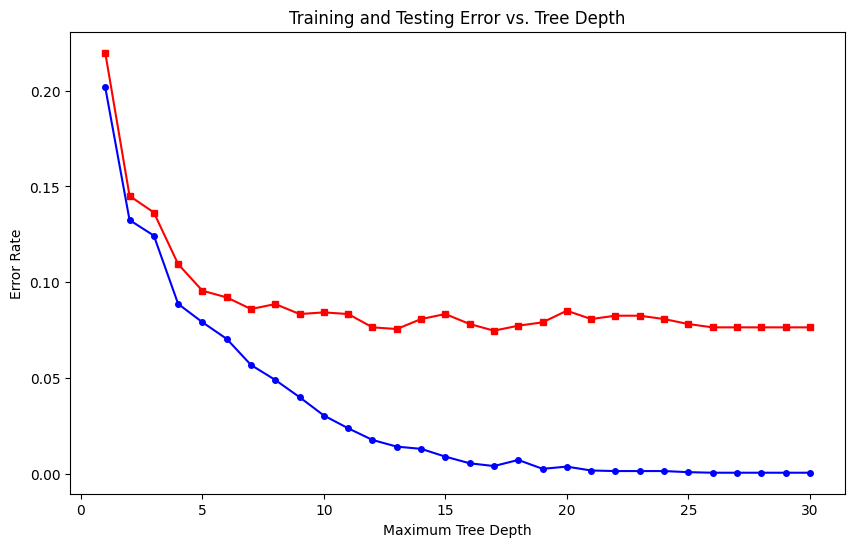

In [ ]:
# 1.3
# Pruning by setting max depth, trying depths 1 to 30

#this is store all training err
train_err_li = []

#this is store all testing err
test_err_li = []

for d in range(1, 31):
    mod3 = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    mod3.fit(X_train, y_train)

    # this will give us traing error
    pred_train3 = mod3.predict(X_train)
    train_err = 1 - accuracy_score(y_train, pred_train3)

    # this will give us testing error
    pred_test3 = mod3.predict(X_test)
    test_err = 1 - accuracy_score(y_test, pred_test3)

    train_err_li.append(train_err)
    test_err_li.append(test_err)

# finding the depth with lowest test error
best_depth = np.argmin(test_err_li) + 1
print("Optimal depth: " + str(best_depth))
print("Test error at optimal depth: " + str(min(test_err_li)))

# plotting train vs test error
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), train_err_li, "b-o", markersize=4, label="Training Error")
plt.plot(range(1, 31), test_err_li, "r-s", markersize=4, label="Testing Error")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Error Rate")
plt.title("Training and Testing Error vs. Tree Depth")
plt.show()